In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import prophet as fbp
from sklearn.metrics import mean_squared_error, mean_absolute_error
# Use fivethirtyeight plot style
plt.style.use('fivethirtyeight')

Importing plotly failed. Interactive plots will not work.


In [4]:
# We will be using amazon share price data which can be downloaded from YAHOO finance website.
df = pd.read_csv('Share-Price-Forecasting-Using-Facebook-Prophet---Dataset.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2015-01-27,15.315000,15.5120,15.131500,15.337500,15.337500,58406000
1,2015-01-28,15.490500,15.5755,15.190000,15.195500,15.195500,61276000
2,2015-01-29,15.236500,15.6400,14.966500,15.589000,15.589000,173132000
3,2015-01-30,17.316000,17.9750,17.037001,17.726500,17.726500,477122000
4,2015-02-02,17.502501,18.2500,17.500500,18.223499,18.223499,204638000


In [5]:
# add two columnsin dataframe having values as Date and Adj Close
df[['ds', 'y']] = df[['Date', 'Adj Close']]
# Subset two columns from data frame
df = df[['ds', 'y']]

df.head()

,ds,y
0,2015-01-27,15.337500
1,2015-01-28,15.195500
2,2015-01-29,15.589000
3,2015-01-30,17.726500
4,2015-02-02,18.223499


In [6]:
# split data frame  into two parts train and test
split_date = "2019-07-21"
df_train = df.loc[df.ds <= split_date].copy()
df_test = df.loc[df.ds > split_date].copy()

In [7]:
# Instantiate prophet 
model = fbp.Prophet()
# fit the training data 
model.fit(df_train)

14:16:25 - cmdstanpy - INFO - Chain [1] start processing
14:16:31 - cmdstanpy - INFO - Chain [1] done processing


In [8]:
forecast = model.predict(df_test)
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
1006,2023-07-20,108.141652,-139.447817,355.842797,-146.840607,348.129601,7.246778,7.246778,7.246778,1.294471,1.294471,1.294471,5.952307,5.952307,5.952307,0.0,0.0,0.0,115.388430
1007,2023-07-21,108.154167,-139.804875,354.381095,-147.384515,348.422591,7.125835,7.125835,7.125835,1.138369,1.138369,1.138369,5.987466,5.987466,5.987466,0.0,0.0,0.0,115.280002
1008,2023-07-24,108.191714,-139.460568,356.186480,-147.903391,348.688479,7.065572,7.065572,7.065572,1.060785,1.060785,1.060785,6.004787,6.004787,6.004787,0.0,0.0,0.0,115.257286
1009,2023-07-25,108.204230,-140.897361,357.651786,-148.447299,348.929335,7.270404,7.270404,7.270404,1.287074,1.287074,1.287074,5.983329,5.983329,5.983329,0.0,0.0,0.0,115.474633
1010,2023-07-26,108.216745,-140.844215,355.560493,-148.991207,349.170192,7.252492,7.252492,7.252492,1.302478,1.302478,1.302478,5.950014,5.950014,5.950014,0.0,0.0,0.0,115.469237


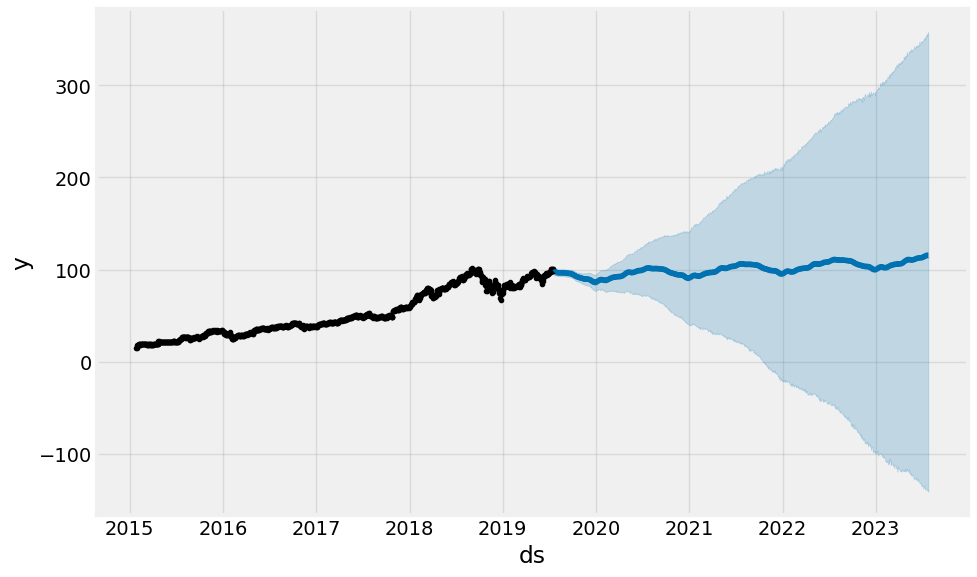

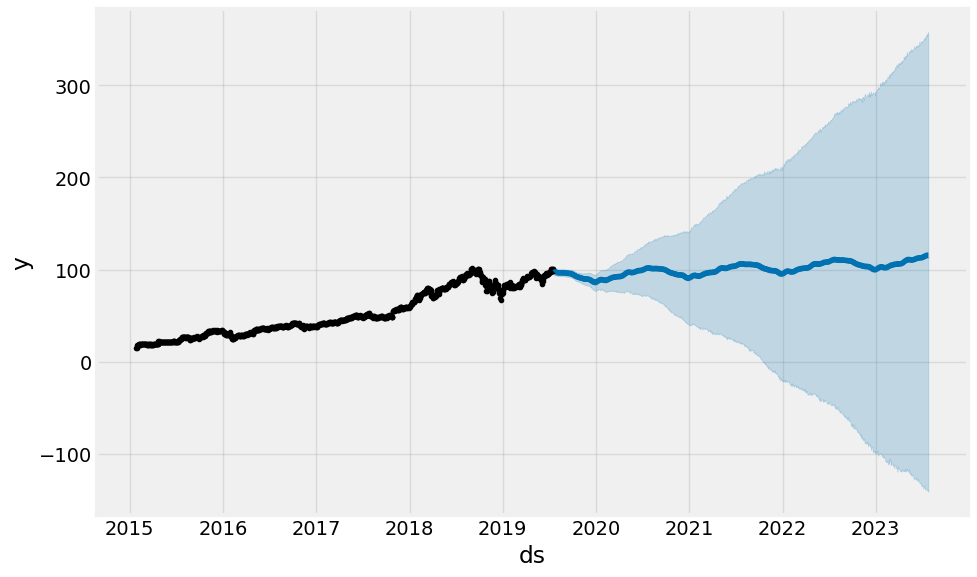

In [9]:
model.plot(forecast)

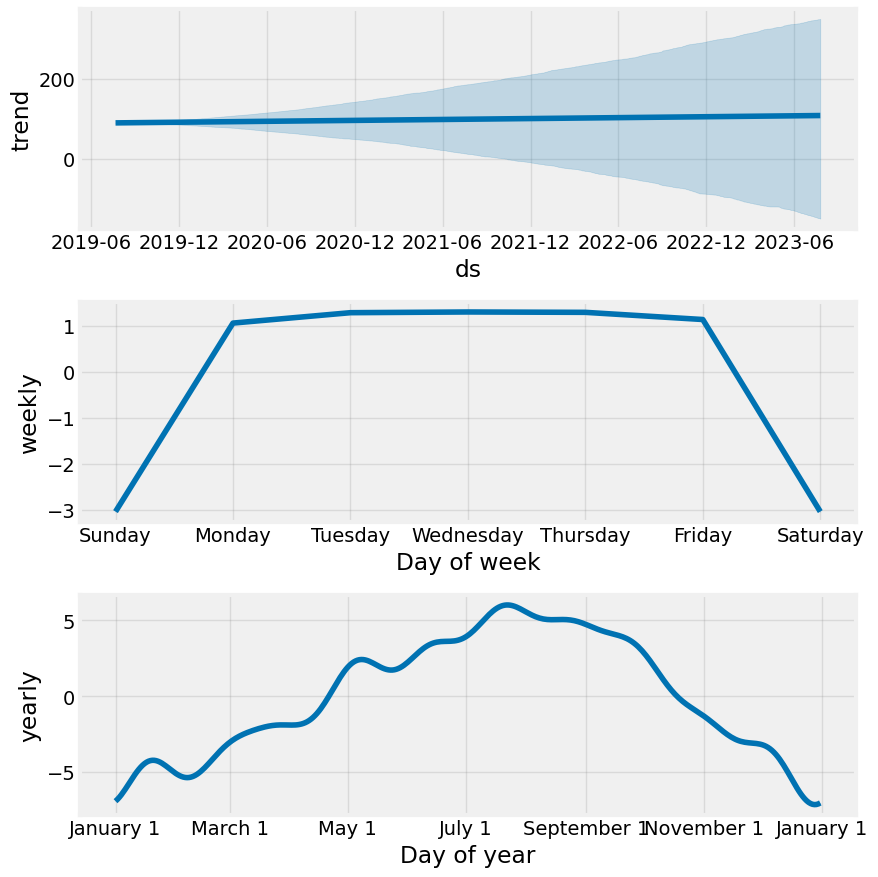

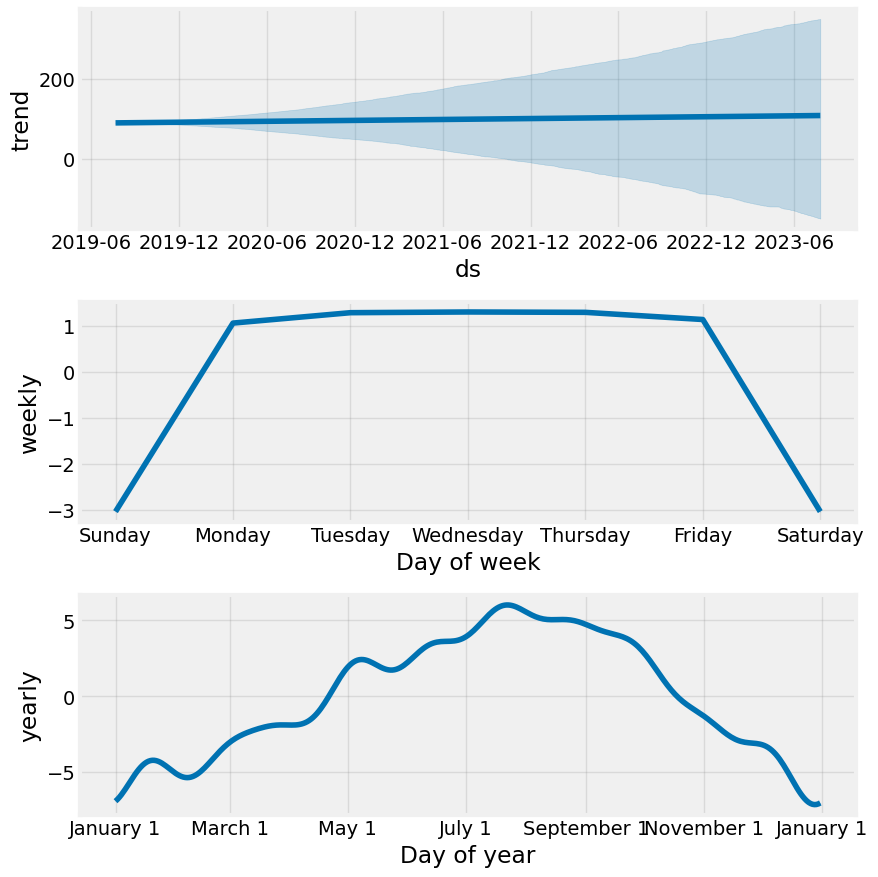

In [10]:
# plot graphs of different components:
model.plot_components(forecast)

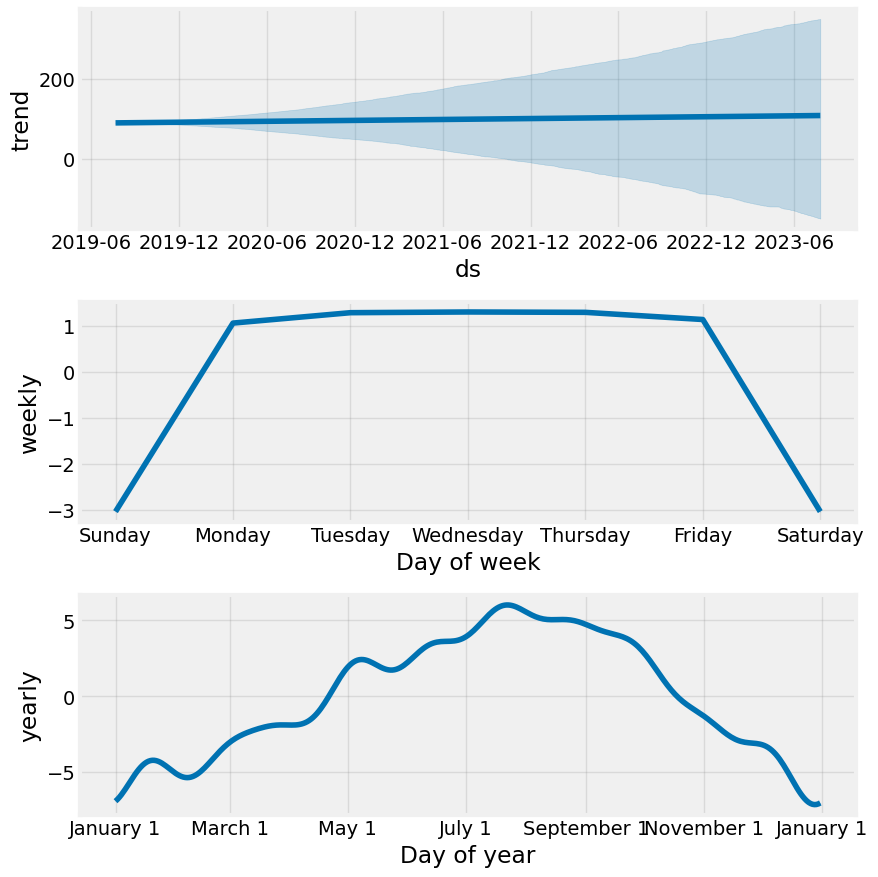

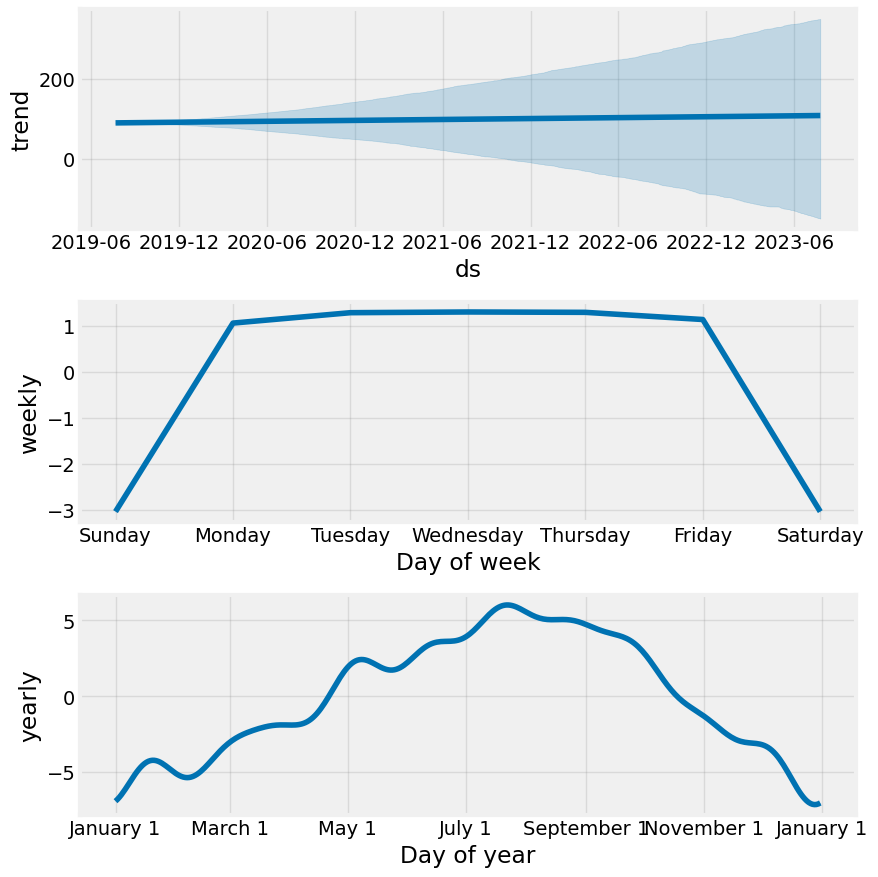

In [11]:
# plot graphs of different components:
model.plot_components(forecast)

In [12]:
# code
print("Mean Squared Error (MSE):", mean_squared_error(y_true = df_test["y"], y_pred = forecast['yhat']))
print("Mean Absolute Error (MAE):", mean_absolute_error(y_true = df_test["y"], y_pred = forecast['yhat']))

Mean Squared Error (MSE): 1953.8905086341326
Mean Absolute Error (MAE): 34.4722277126008


In [13]:
def mean_abs_perc_err(y_true, y_pred): 
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("Mean Absolute % Error (MAPE): ", mean_abs_perc_err(y_true = np.asarray(df_test["y"]), y_pred = np.asarray(forecast['yhat'])))

Mean Absolute % Error (MAPE):  22.71283606759608
